In [73]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2
from imports import *

In [74]:
from config import dir_config
from src.utils import pmf_utils, classification_utils

raw_dir = Path(dir_config.data.raw)
processed_dir = Path(dir_config.data.processed)

filtered_data = pd.read_csv(Path(processed_dir, "processed_all_data_accu_60_filtered.csv"), index_col=None)
metadata = pd.read_csv(Path(processed_dir, "processed_metadata_all_data_accu_60.csv"), index_col=None)


In [75]:
subjects_map, grp_indices = classification_utils.get_subject_classification_ids(metadata)


PD subjects with ON+OFF sessions: 41
PD subjects with UPDRS subtype: 22
All PD subjects:           41
  Tremor dominant:         11 	 ['P3' 'P6' 'P7' 'P11' 'P12' 'P17' 'P18' 'P19' 'P29' 'P31' 'P32']
  Brady dominant:          10 	 ['P1' 'P4' 'P9' 'P13' 'P20' 'P22' 'P23' 'P28' 'P33' 'P34']
  Intermediate:            1 	 ['P24']
HC subjects:               18 	 ['HC1' 'HC3' 'HC6' 'HC7' 'HC8' 'HC9' 'HC12' 'HC13' 'AV' 'BC' 'BF' 'EM'
 'ES' 'GF' 'GP' 'JA' 'MRM' 'SY']


## Plot group-wise psychometric function

In [85]:
def new_accumulators():
    """Empty accumulators for psychometric data."""
    return {k: {"coh": [], "psych": [], "model": [], "x_hat": [], "y_hat": []} for k in ("overall",)}


def collect_psych(data, accum):
    """Fit psychometric data and append to accum."""
    coh, psych, model, x_hat, y_hat = pmf_utils.get_psychometric_data(data)
    for field, val in zip(["coh", "psych", "model", "x_hat", "y_hat"], [coh, psych, model, x_hat, y_hat]):
        accum["overall"][field].append(val)


def plot_mean_psych(ax, accum, color, err_style):
    """Plot group-mean psychometric curve with error bars and fitted line."""
    coh_arr = np.array(accum["overall"]["coh"])
    psych_arr = np.array(accum["overall"]["psych"])
    x_hat_arr = np.array(accum["overall"]["x_hat"])
    mean_coh, mean_psych = np.mean(coh_arr, axis=0), np.mean(psych_arr, axis=0)
    mean_x_hat = np.mean(x_hat_arr, axis=0)
    ax.plot(mean_coh, mean_psych, color=color, ls="", marker="o", ms=12, mec="k")
    ax.errorbar(mean_coh, mean_psych, yerr=stats.sem(psych_arr, axis=0), color=color, ls="", marker="o", ms=12, mec="k", **err_style)
    fit = pmf_utils.fit_psychometric_function(mean_coh, mean_psych, trial_counts=None, model_type="logit_4")
    ax.plot(mean_x_hat, fit.predict(mean_x_hat), color=color, ls="-", lw=4)

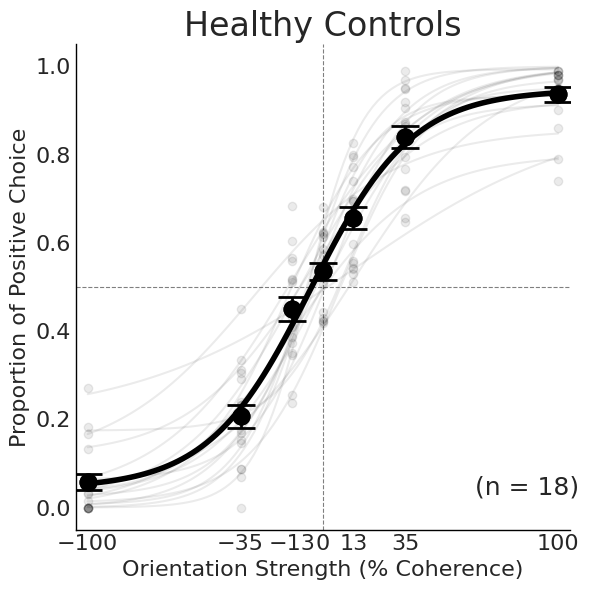

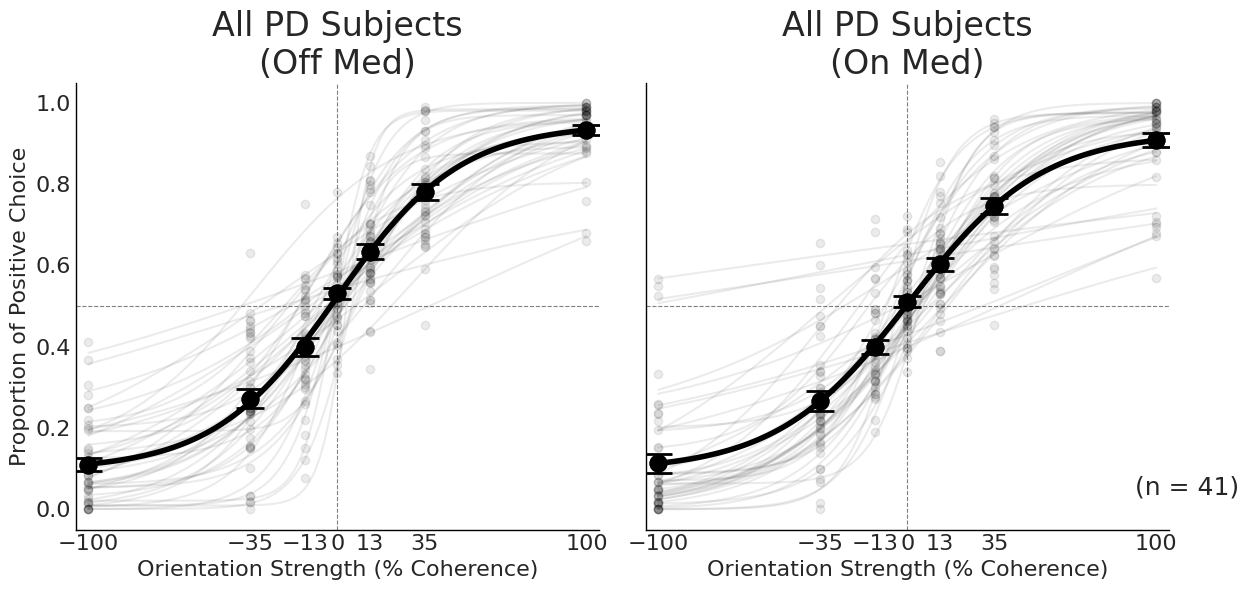

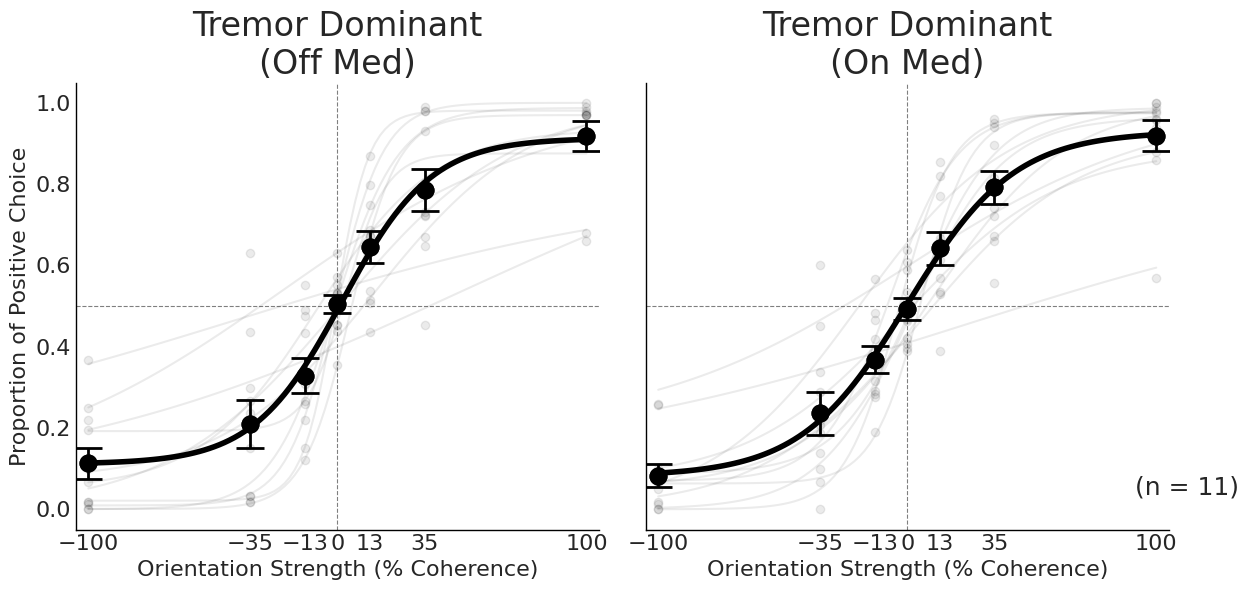

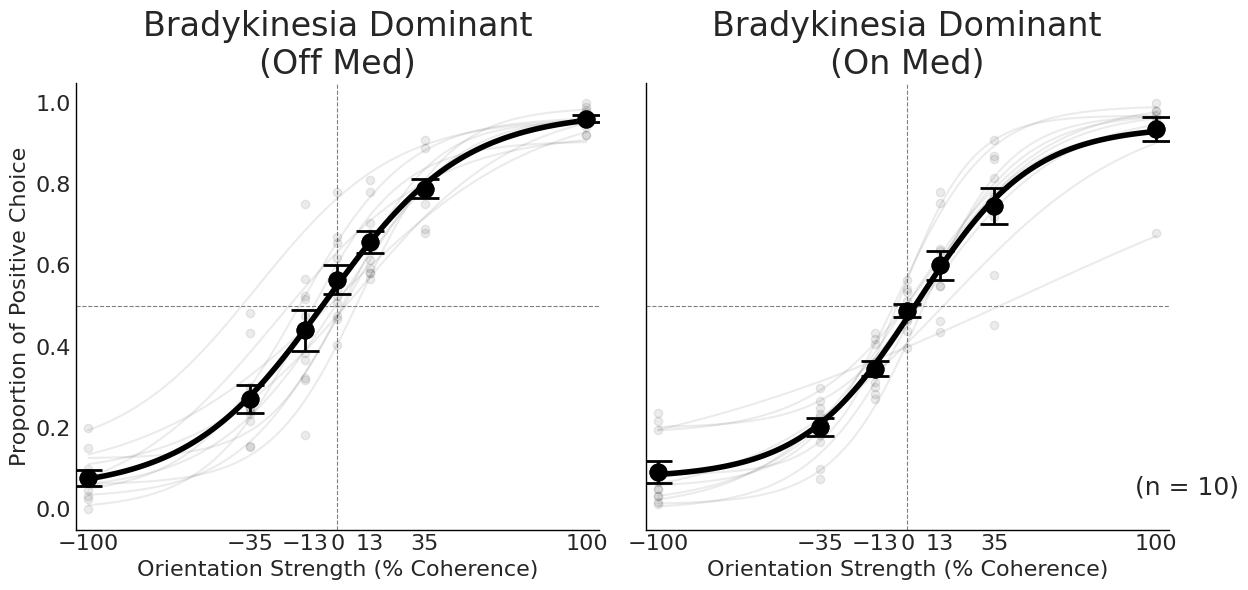

In [84]:
overall_color = "k"
alpha = 0.08
err_style = {"elinewidth": 2, "capsize": 10, "capthick": 2}

pos_color, eq_color = "#C2B39F", "#8C5A96"
alpha = 0.08
err_style = {"elinewidth": 2, "capsize": 10, "capthick": 2}
suptitle_map = {
    "all": "All PD Subjects",
    "tremor_dominant": "Tremor Dominant",
    "bradykinesia_dominant": "Bradykinesia Dominant",
    "healthy": "Healthy Controls",
}
for group, sub_ids in subjects_map.items():
    suptitle = suptitle_map[group]
    if group != "healthy":
        fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
    else:
        fig, _ax = plt.subplots(1, 1, figsize=(6, 6))
        ax = np.array([_ax])

    off, on = new_accumulators(), new_accumulators()
    for sid in sub_ids:
        subj_data = filtered_data[filtered_data["subject_id"] == sid].sort_values("medication")

        if group == "healthy":
            collect_psych(subj_data, off)
            ax[0].plot(off["overall"]["coh"][-1], off["overall"]["psych"][-1], color=overall_color, marker="o", ls="", alpha=alpha)
            ax[0].plot(off["overall"]["x_hat"][-1], off["overall"]["y_hat"][-1], color=overall_color, ls="-", alpha=alpha)
        else:
            for med in subj_data["medication"].unique():
                accum, ax_i = (off, 0) if med == "off" else (on, 1)
                collect_psych(subj_data[subj_data["medication"] == med], accum)
                ax[ax_i].plot(accum["overall"]["coh"][-1], accum["overall"]["psych"][-1], color=overall_color, marker="o", ls="", alpha=alpha)
                ax[ax_i].plot(accum["overall"]["x_hat"][-1], accum["overall"]["y_hat"][-1], color=overall_color, ls="-", alpha=alpha)
    if group != "healthy":
        plot_mean_psych(ax[0], off, overall_color, err_style)
        plot_mean_psych(ax[1], on, overall_color, err_style)
        for a in ax:
            a.axhline(0.5, color="k", lw=0.8, ls="--", alpha=0.5)
            a.axvline(0, color="k", lw=0.8, ls="--", alpha=0.5)
    else:
        plot_mean_psych(ax[0], off, overall_color, err_style)
        ax[0].axhline(0.5, color="k", lw=0.8, ls="--", alpha=0.5)
        ax[0].axvline(0, color="k", lw=0.8, ls="--", alpha=0.5)

    # ── Styling ──
    for a in ax:
        a.set_xticks([-100, -35, -13, 0, 13, 35, 100])
        a.tick_params(labelsize=16)
        for sp in ["top", "right"]:
            a.spines[sp].set_visible(False)
    ax[0].set(xlabel="Orientation Strength (% Coherence)", ylabel="Proportion of Positive Choice", xlim=(-105, 105), ylim=(-0.05, 1.05), title=f"{suptitle}{'' if group == 'healthy' else '\n(Off Med)'}")
    if group != "healthy":
        ax[1].set(xlabel="Orientation Strength (% Coherence)", xlim=(-105, 105), ylim=(-0.05, 1.05), title=f"{suptitle}\n(On Med)")
        fig.text(0.95, 0.2, f"(n = {len(sub_ids)})", fontsize=18, ha="left", va="top")
    else:
        fig.text(0.8, 0.2, f"(n = {len(sub_ids)})", fontsize=18, ha="left", va="top")
    fig.tight_layout()

## Statistical tests on PMF params

In [78]:
psych_columns = [
    "overall_bias",
    "overall_psych_alpha",
    "overall_psych_beta",
]

psych_params = metadata[psych_columns]


## Group comparisons on overall PMF parameters

Between-group (unpaired): HC vs Tremor OFF, HC vs Brady OFF, Tremor OFF vs Brady OFF — Mann-Whitney U.  
Within-group (paired): Tremor OFF vs ON, Brady OFF vs ON — Wilcoxon signed-rank.  
Bonferroni correction across all 5 comparisons per parameter.

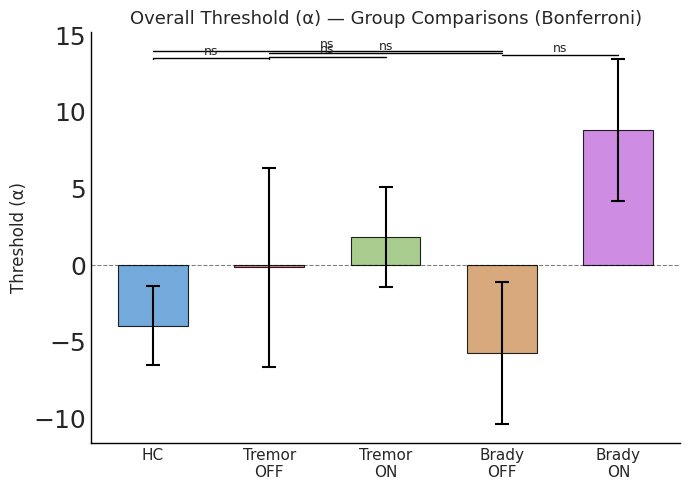

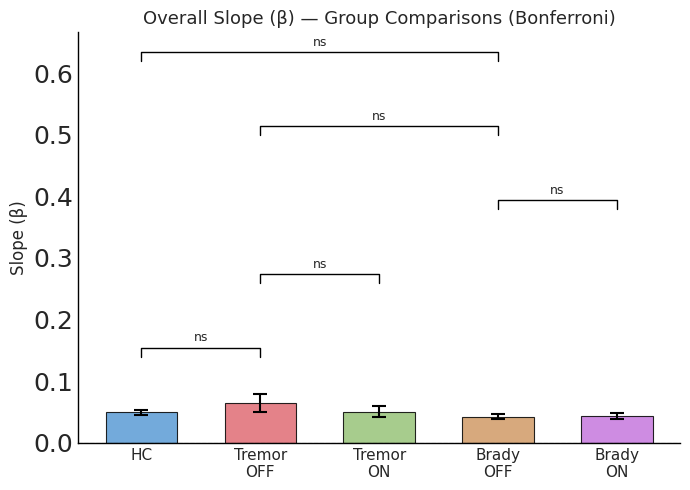

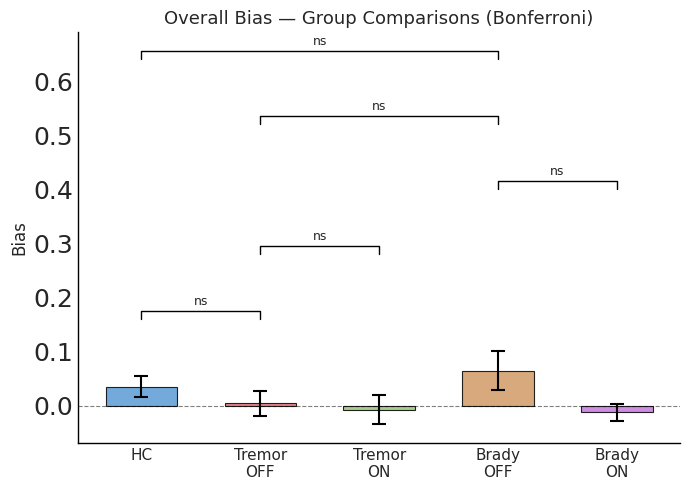

In [79]:
from scipy import stats as scipy_stats
from statsmodels.stats.multitest import multipletests

overall_vars = {
    "overall_psych_alpha": "Threshold (α)",
    "overall_psych_beta":  "Slope (β)",
    "overall_bias":        "Bias",
}

plot_groups = ["healthy", "tremor_off", "tremor_on", "brady_off", "brady_on"]
group_labels = {
    "healthy":    "HC",
    "tremor_off": "Tremor\nOFF",
    "tremor_on":  "Tremor\nON",
    "brady_off":  "Brady\nOFF",
    "brady_on":   "Brady\nON",
}
group_colors = ["#5B9BD5", "#E06C75", "#98C379", "#D19A66", "#C678DD"]

# (group_a, group_b, paired)
comparisons = [
    ("healthy",    "tremor_off", False),  # unpaired → Mann-Whitney U
    ("tremor_off", "tremor_on",  True),   # paired   → Wilcoxon
    ("healthy",    "brady_off",  False),  # unpaired → Mann-Whitney U
    ("brady_off",  "brady_on",   True),   # paired   → Wilcoxon
    ("tremor_off", "brady_off",  False),  # unpaired → Mann-Whitney U
]
group_xi = {g: i for i, g in enumerate(plot_groups)}


def _sig_stars(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"


def _get_paired(col, grp_a, grp_b):
    """Align OFF/ON series by subject position, drop NaNs jointly to preserve pairing."""
    a = metadata.loc[grp_indices[grp_a], col].reset_index(drop=True)
    b = metadata.loc[grp_indices[grp_b], col].reset_index(drop=True)
    paired = pd.DataFrame({"a": a, "b": b}).dropna()
    return paired["a"].values, paired["b"].values


for col, col_label in overall_vars.items():
    is_bias = col == "overall_bias"

    # collect raw p-values for Bonferroni correction
    raw_ps = []
    for grp_a, grp_b, paired in comparisons:
        if paired:
            a, b = _get_paired(col, grp_a, grp_b)
            if is_bias:
                a, b = a - 0.5, b - 0.5
            _, p = scipy_stats.wilcoxon(a, b)
        else:
            a = metadata.loc[grp_indices[grp_a], col].dropna().values
            b = metadata.loc[grp_indices[grp_b], col].dropna().values
            if is_bias:
                a, b = a - 0.5, b - 0.5
            _, p = scipy_stats.mannwhitneyu(a, b, alternative="two-sided")
        raw_ps.append(p)

    _, corr_ps, _, _ = multipletests(raw_ps, method="bonferroni")

    # bar plot
    fig, ax = plt.subplots(figsize=(7, 5))
    bar_tops = []

    for xi, (grp, color) in enumerate(zip(plot_groups, group_colors)):
        vals = metadata.loc[grp_indices[grp], col].dropna().values
        if is_bias:
            vals = vals - 0.5
        mean = vals.mean()
        sem  = scipy_stats.sem(vals)
        ax.bar(xi, mean, color=color, edgecolor="k", linewidth=0.8, width=0.6, alpha=0.85)
        ax.errorbar(xi, mean, yerr=sem, fmt="none", color="k", capsize=5, elinewidth=1.5, capthick=1.5)
        bar_tops.append(mean + sem)

    # stack brackets shortest span first to avoid overlap
    span_order = sorted(
        enumerate(comparisons), key=lambda x: abs(group_xi[x[1][1]] - group_xi[x[1][0]])
    )
    bracket_base = max(bar_tops) + 0.06
    bracket_step = 0.12

    for rank, (i, (grp_a, grp_b, _)) in enumerate(span_order):
        xi_a, xi_b = group_xi[grp_a], group_xi[grp_b]
        y = bracket_base + rank * bracket_step
        p_adj = corr_ps[i]
        ax.plot([xi_a, xi_a, xi_b, xi_b], [y, y + 0.015, y + 0.015, y], color="k", lw=1)
        ax.text((xi_a + xi_b) / 2, y + 0.02, _sig_stars(p_adj), ha="center", va="bottom", fontsize=9)

    ax.axhline(0, color="k", lw=0.8, ls="--", alpha=0.5)
    ax.set_xticks(range(len(plot_groups)))
    ax.set_xticklabels([group_labels[g] for g in plot_groups], fontsize=11)
    ax.set_ylabel(col_label, fontsize=12)
    ax.set_title(f"Overall {col_label} — Group Comparisons (Bonferroni)", fontsize=13)
    ax.grid(False)
    plt.tight_layout()
    plt.show()


### Comparison between tremor_off and brady_off

In [81]:
from scipy.stats import mannwhitneyu
import numpy as np

# Average slope across both prior conditions per subject, then compare groups
trem_data = psych_params.loc[grp_indices["tremor_off"]]
brady_data = psych_params.loc[grp_indices["brady_off"]]

trem_beta = trem_data["overall_psych_beta"]
brady_beta = brady_data["overall_psych_beta"]

stat, p = mannwhitneyu(trem_beta, brady_beta, alternative="two-sided")

print("Psychometric slope (beta) — Tremor OFF vs Brady OFF — Mann-Whitney U")
print(f"  Tremor OFF (n={len(trem_beta)}):  mean beta = {trem_beta.mean():.4f} ± {trem_beta.std():.4f}")
print(f"  Brady OFF  (n={len(brady_beta)}): mean beta = {brady_beta.mean():.4f} ± {brady_beta.std():.4f}")
print(f"  U = {stat:.1f}, p = {p:.3f}")


Psychometric slope (beta) — Tremor OFF vs Brady OFF — Mann-Whitney U
  Tremor OFF (n=11):  mean beta = 0.0644 ± 0.0499
  Brady OFF  (n=10): mean beta = 0.0424 ± 0.0114
  U = 59.0, p = 0.805


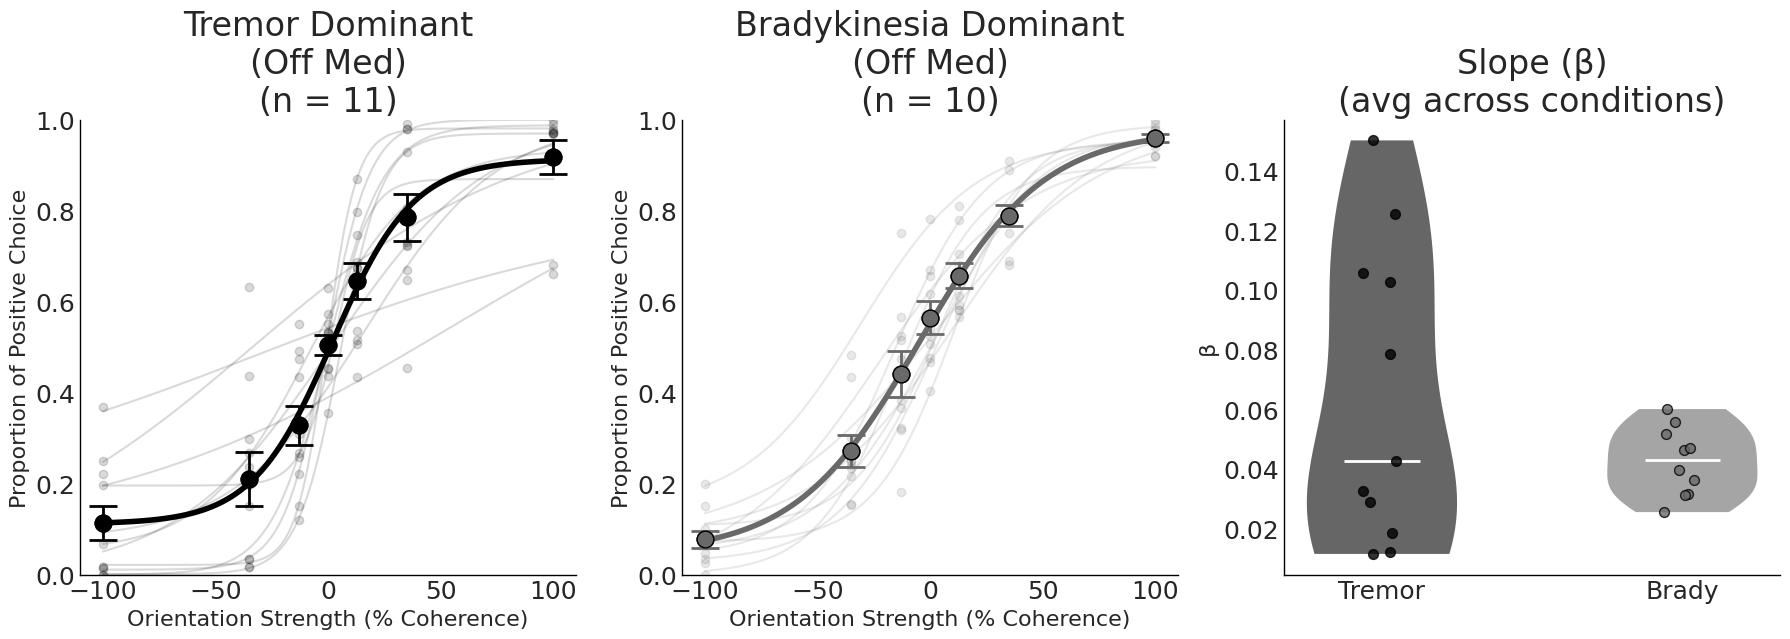

In [86]:
from scipy import stats as scipy_stats


def get_combined_psych(data):
    """Average psychometric data across both prior conditions, return data + fitted curve."""
    results = {}
    coh, psych, _, x_hat, _ = pmf_utils.get_psychometric_data(data)
    results = {"coh": coh, "psych": psych, "x_hat": x_hat}
    coh = results["coh"]
    mean_psych = results["psych"]
    x_hat = results["x_hat"]
    fit = pmf_utils.fit_psychometric_function(coh, mean_psych, trial_counts=None, model_type="logit_4")
    return coh, mean_psych, x_hat, fit.predict(x_hat)


fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))
err_style = {"elinewidth": 2, "capsize": 10, "capthick": 2}

group_cfg = [
    ("Tremor Dominant\n(Off Med)", "tremor_off", "black"),
    ("Bradykinesia Dominant\n(Off Med)", "brady_off", "dimgray"),
]

for ax, (title, grp_key, color) in zip(axes[:2], group_cfg):
    sub_ids = metadata.loc[grp_indices[grp_key], "subject_id"]
    coh_list, psych_list, x_hat_list = [], [], []

    for sid in sub_ids:
        subj_data = filtered_data[(filtered_data["subject_id"] == sid) & (filtered_data["medication"] == "off")]
        if len(subj_data) == 0:
            continue
        coh, psych, x_hat, y_hat = get_combined_psych(subj_data)
        coh_list.append(coh)
        psych_list.append(psych)
        x_hat_list.append(x_hat)
        ax.plot(coh, psych, color=color, marker="o", ls="", alpha=0.15)
        ax.plot(x_hat, y_hat, color=color, ls="-", lw=1.5, alpha=0.15)

    coh_arr = np.array(coh_list)
    psych_arr = np.array(psych_list)
    mean_coh = np.mean(coh_arr, axis=0)
    mean_psych = np.mean(psych_arr, axis=0)
    mean_x_hat = np.mean(np.array(x_hat_list), axis=0)

    ax.plot(mean_coh, mean_psych, color=color, ls="", marker="o", ms=12, mec="k")
    ax.errorbar(mean_coh, mean_psych, yerr=scipy_stats.sem(psych_arr, axis=0), color=color, ls="", marker="o", ms=12, mec="k", **err_style)
    fit = pmf_utils.fit_psychometric_function(mean_coh, mean_psych, trial_counts=None, model_type="logit_4")
    ax.plot(mean_x_hat, fit.predict(mean_x_hat), color=color, ls="-", lw=4)
    ax.set(xlabel="Orientation Strength (% Coherence)", ylabel="Proportion of Positive Choice", ylim=(0, 1), title=f"{title}\n(n = {len(psych_list)})")
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

# Violin plot for slope comparison
beta_ax = axes[2]
trem_beta = metadata.loc[grp_indices["tremor_off"], "overall_psych_beta"]
brady_beta = metadata.loc[grp_indices["brady_off"], "overall_psych_beta"]

parts = beta_ax.violinplot([trem_beta.values, brady_beta.values], positions=[0, 1], showmedians=True, showextrema=False)
for pc, color in zip(parts["bodies"], ["black", "dimgray"]):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)
parts["cmedians"].set_color("white")
parts["cmedians"].set_linewidth(2)

for xi, vals, color in [(0, trem_beta.values, "black"), (1, brady_beta.values, "dimgray")]:
    beta_ax.scatter(np.random.normal(xi, 0.04, size=len(vals)), vals, color=color, edgecolor="k", s=50, zorder=3, alpha=0.8)

beta_ax.set_xticks([0, 1])
beta_ax.set_xticklabels(["Tremor", "Brady"])
beta_ax.set(title="Slope (β)\n(avg across conditions)", ylabel="β")
for sp in ["top", "right"]:
    beta_ax.spines[sp].set_visible(False)

plt.tight_layout()
plt.show()